# BDA Practica 2 — Knowledge Graph Exploration

This notebook explores the **RDF/RDFS Knowledge Graph** produced by the Exploitation Zone and runs the SPARQL analytical pipeline.

It is one of two analytical pipelines required by the P2 statement:

> Implement at least two Data Analysis pipelines:
> - 1 based on **pattern matching queries using SPARQL**
> - 1 based on running an **ML algorithm over the KG embeddings**

The first is showcased here. The second (KG embeddings + classifier) is showcased in `03_model_comparison_and_explainability.ipynb`.

Run the full pipeline (`python run_all_pipeline.py --skip-landing --strict`) before executing this notebook.

## 1. Setup and Manifest

Locate the project root, the KG artefacts and the manifest that links them.

In [15]:
from pathlib import Path
import json

import pandas as pd
from rdflib import Graph
try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    print(f'Matplotlib unavailable; showing tables only: {exc}')


def locate_project_root(start: Path) -> Path:
    current = start.resolve()
    for _ in range(8):
        if (current / 'run_all_pipeline.py').exists():
            return current
        current = current.parent
    raise FileNotFoundError('Could not locate project root')

PROJECT_ROOT = locate_project_root(Path.cwd())
KG_ROOT = PROJECT_ROOT / 'Part4_Exploitation_zone' / 'exploitation_zone' / 'kg'
MANIFEST_PATH = KG_ROOT / 'kg_manifest.json'
REPORT_PATH = PROJECT_ROOT / 'Part5_Analysis_zone' / 'reports' / 'kg_analysis_report.json'

def resolve_kg_path(path_text: str) -> Path:
    path = Path(path_text)
    if path.exists():
        return path
    fallback = KG_ROOT / path.name
    if fallback.exists():
        return fallback
    return path


def resolve_sparql_dir(path_text: str) -> Path:
    path = Path(path_text)
    if path.exists():
        return path
    fallback = KG_ROOT / 'sparql'
    if fallback.exists():
        return fallback
    return path

manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
report = json.loads(REPORT_PATH.read_text(encoding='utf-8')) if REPORT_PATH.exists() else None

print('Manifest run_id        :', manifest['run_id'])
print('Created at (UTC)       :', manifest['created_at_utc'])
print('Language               :', manifest['language'])
print('Generator              :', manifest['generator'])
print('Trusted rows processed :', manifest['counts']['trusted_rows_processed'])
print('Health record resources:', manifest['counts']['health_record_resources'])
print('Aggregate measurements :', manifest['counts']['aggregate_measurements'])
print('Total triples (full)   :', manifest['counts']['triples'])


Manifest run_id        : 20260601_153001
Created at (UTC)       : 2026-06-01T15:30:54+00:00
Language               : RDF/RDFS
Generator              : RDFLib
Trusted rows processed : 322587
Health record resources: 322587
Aggregate measurements : 645
Total triples (full)   : 3635316


## 2. Load the Analytics Graph

The pipeline produces two Turtle files:
- `health_risk_kg.ttl` — the full graph with one `hr:HealthRecord` per cleaned trusted row.
- `health_risk_analytics_kg.ttl` — the compact graph with only schema, vocabulary and `hr:AggregateMeasurement` resources, much faster to query.

We use the analytics graph for interactive exploration.

In [16]:
analytics_graph_path = resolve_kg_path(manifest['storage']['analytics_graph_file'])
analytics_graph_format = 'nt' if analytics_graph_path.suffix.lower() == '.nt' else 'turtle'

graph = Graph()
graph.parse(str(analytics_graph_path), format=analytics_graph_format)
print(f'Loaded analytics KG: {len(graph):,} triples from {analytics_graph_path}')


Loaded analytics KG: 5,573 triples from /mnt/c/Users/Paess/Documents/GitHub/bda-practica2/Part4_Exploitation_zone/exploitation_zone/kg/health_risk_analytics_kg.ttl


## 3. Graph Structure Summary

Quick counts of the main classes confirm the schema is populated correctly.

In [17]:
STRUCTURE_QUERIES = {
    'Datasets': 'SELECT (COUNT(DISTINCT ?x) AS ?n) WHERE { ?x a hr:Dataset }',
    'Age groups': 'SELECT (COUNT(DISTINCT ?x) AS ?n) WHERE { ?x a hr:AgeGroup }',
    'Genders': 'SELECT (COUNT(DISTINCT ?x) AS ?n) WHERE { ?x a hr:Gender }',
    'Population groups': 'SELECT (COUNT(DISTINCT ?x) AS ?n) WHERE { ?x a hr:PopulationGroup }',
    'Indicators': 'SELECT (COUNT(DISTINCT ?x) AS ?n) WHERE { ?x a hr:Indicator }',
    'Outcomes': 'SELECT (COUNT(DISTINCT ?x) AS ?n) WHERE { ?x a hr:Outcome }',
    'Aggregate measurements': 'SELECT (COUNT(DISTINCT ?x) AS ?n) WHERE { ?x a hr:AggregateMeasurement }',
}
prefix = 'PREFIX hr: <https://example.org/bda/health-risk/>'
rows = []
for label, q in STRUCTURE_QUERIES.items():
    result = list(graph.query(f'{prefix} {q}'))
    rows.append({'class': label, 'instances': int(result[0][0]) if result else 0})
structure_df = pd.DataFrame(rows)
structure_df

,class,instances
0,Datasets,3
1,Age groups,13
2,Genders,3
3,Population groups,26
4,Indicators,17
5,Outcomes,3
6,Aggregate measurements,645


## 4. SPARQL Pattern-Matching Analysis

The Exploitation Zone writes a catalogue of `.rq` files in `exploitation_zone/kg/sparql/`. The analytical pipeline (`kg_analysis_pipeline.py`) runs a curated subset of them. Each query exploits the graph structure in a way that would be cumbersome to express over flat SQL tables.

In [18]:
def query_to_df(graph: Graph, query_text: str) -> pd.DataFrame:
    results = graph.query(query_text)
    var_names = [str(v) for v in results.vars]
    data = []
    for row in results:
        record = {}
        for var in results.vars:
            value = row[var]
            if value is None:
                record[str(var)] = None
            elif hasattr(value, 'toPython'):
                record[str(var)] = value.toPython()
            else:
                record[str(var)] = str(value)
        data.append(record)
    return pd.DataFrame(data, columns=var_names)


SPARQL_DIR = resolve_sparql_dir(manifest['storage']['sparql_query_dir'])
for path in sorted(SPARQL_DIR.glob('*.rq')):
    print(path.name)

01_entities_by_population_group.rq
02_indicators_shared_by_datasets.rq
03_rank_population_groups_by_outcome_rate.rq
04_combine_indicators_same_group.rq
05_population_groups_connected_to_multiple_sources.rq
06_indicator_consistency_across_datasets.rq
07_outcome_rate_by_age_group.rq
08_top_risk_factor_cooccurrence.rq


### 4.1 Indicators shared by multiple datasets

This query proves that the **common vocabulary** required by P2 is doing its job: the same `hr:Indicator` IRIs are referenced by aggregate measurements from more than one dataset.

In [19]:
shared = query_to_df(graph, (SPARQL_DIR / '02_indicators_shared_by_datasets.rq').read_text())
shared = shared.sort_values('datasetCount', ascending=False)
shared

,indicator,label,datasetCount
0,https://example.org/bda/health-risk/indicator/...,Age in years or age-band proxy,3
1,https://example.org/bda/health-risk/indicator/...,Heart disease outcome,3
2,https://example.org/bda/health-risk/indicator/...,High blood pressure flag,3
3,https://example.org/bda/health-risk/indicator/...,High cholesterol flag,3
4,https://example.org/bda/health-risk/indicator/...,Body mass index,2
5,https://example.org/bda/health-risk/indicator/...,Glucose risk flag,2
6,https://example.org/bda/health-risk/indicator/...,Heavy alcohol consumption flag,2
7,https://example.org/bda/health-risk/indicator/...,Physical activity flag,2
8,https://example.org/bda/health-risk/indicator/...,Smoking flag,2
9,https://example.org/bda/health-risk/indicator/...,Systolic blood pressure,2


### 4.2 Highest-risk population groups

Rank `hr:PopulationGroup` × `hr:Dataset` pairs by the positive heart-disease rate of the aggregate measurement linked through `hr:hasOutcome`. We restrict to groups with at least 25 observations to drop noisy buckets.

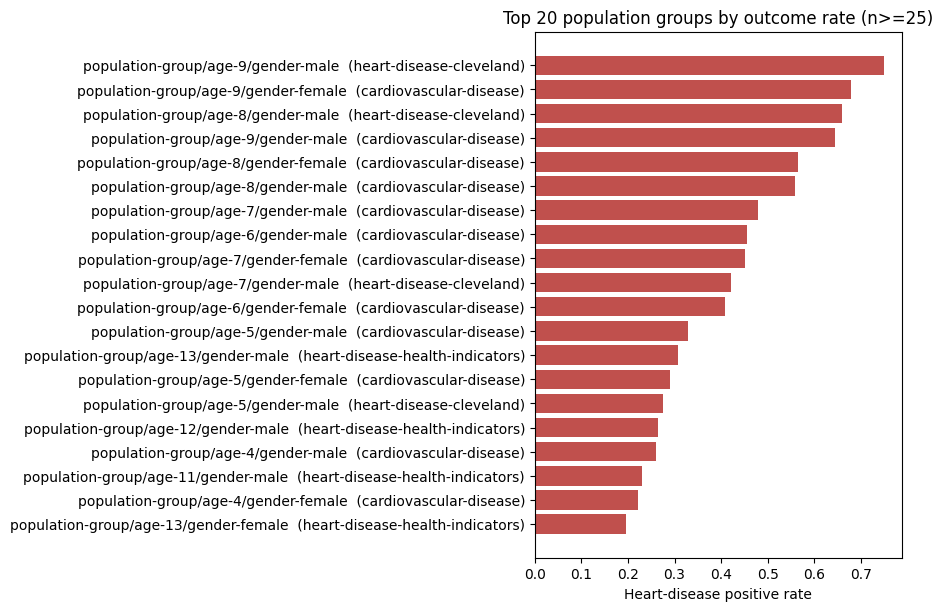

,shortGroup,dataset,positiveRate,observations
0,population-group/age-9/gender-male,https://example.org/bda/health-risk/dataset/he...,0.750000,28
1,population-group/age-9/gender-female,https://example.org/bda/health-risk/dataset/ca...,0.679566,8011
2,population-group/age-8/gender-male,https://example.org/bda/health-risk/dataset/he...,0.660000,50
3,population-group/age-9/gender-male,https://example.org/bda/health-risk/dataset/ca...,0.644910,4489
4,population-group/age-8/gender-female,https://example.org/bda/health-risk/dataset/ca...,0.564067,12167
5,population-group/age-8/gender-male,https://example.org/bda/health-risk/dataset/ca...,0.558466,5918
6,population-group/age-7/gender-male,https://example.org/bda/health-risk/dataset/ca...,0.478221,5487
7,population-group/age-6/gender-male,https://example.org/bda/health-risk/dataset/ca...,0.456107,4192
8,population-group/age-7/gender-female,https://example.org/bda/health-risk/dataset/ca...,0.451776,11260
9,population-group/age-7/gender-male,https://example.org/bda/health-risk/dataset/he...,0.421053,38


In [20]:
ranked = query_to_df(graph, (SPARQL_DIR / '03_rank_population_groups_by_outcome_rate.rq').read_text())
ranked = ranked.head(20)
ranked['shortGroup'] = ranked['populationGroup'].str.replace('https://example.org/bda/health-risk/', '', regex=False)
if plt is not None:
    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    ax.barh(ranked['shortGroup'] + '  (' + ranked['dataset'].str.split('/').str[-1] + ')',
            ranked['positiveRate'].astype(float),
            color='#C0504D')
    ax.set_xlabel('Heart-disease positive rate')
    ax.set_title('Top 20 population groups by outcome rate (n>=25)')
    ax.invert_yaxis()
    plt.show()
ranked[['shortGroup', 'dataset', 'positiveRate', 'observations']].head(10)


### 4.3 Combining indicators for the same population

For each group we read three aggregate measurements via `OPTIONAL` patterns. This is the kind of query a graph database makes natural — the equivalent SQL would require multiple self-joins.


In [21]:
combined = query_to_df(graph, (SPARQL_DIR / '04_combine_indicators_same_group.rq').read_text())
for col in ['heartDiseaseRate', 'highBpRate', 'highCholesterolRate']:
    if col in combined.columns:
        combined[col] = pd.to_numeric(combined[col], errors='coerce')
combined.head(20)

,populationGroup,dataset,heartDiseaseRate,highBpRate,highCholesterolRate
0,https://example.org/bda/health-risk/population...,https://example.org/bda/health-risk/dataset/he...,1.000000,0.000000,1.000000
1,https://example.org/bda/health-risk/population...,https://example.org/bda/health-risk/dataset/he...,0.750000,1.000000,0.750000
2,https://example.org/bda/health-risk/population...,https://example.org/bda/health-risk/dataset/he...,0.750000,0.642857,0.892857
3,https://example.org/bda/health-risk/population...,https://example.org/bda/health-risk/dataset/he...,0.736842,0.526316,0.894737
4,https://example.org/bda/health-risk/population...,https://example.org/bda/health-risk/dataset/ca...,0.679566,0.880539,0.345775
5,https://example.org/bda/health-risk/population...,https://example.org/bda/health-risk/dataset/he...,0.660000,0.640000,0.840000
6,https://example.org/bda/health-risk/population...,https://example.org/bda/health-risk/dataset/ca...,0.644910,0.893295,0.288928
7,https://example.org/bda/health-risk/population...,https://example.org/bda/health-risk/dataset/he...,0.571429,0.285714,0.714286
8,https://example.org/bda/health-risk/population...,https://example.org/bda/health-risk/dataset/ca...,0.564067,0.847374,0.304019
9,https://example.org/bda/health-risk/population...,https://example.org/bda/health-risk/dataset/ca...,0.558466,0.879689,0.264954


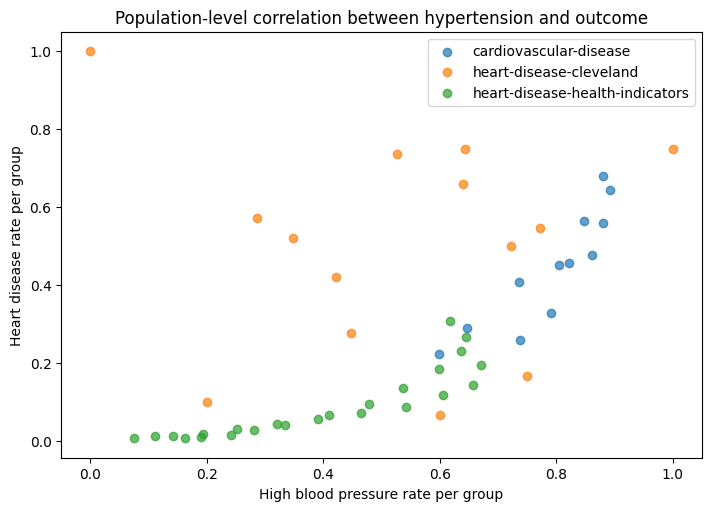

,dataset,heartDiseaseRate,highBpRate,highCholesterolRate
0,https://example.org/bda/health-risk/dataset/he...,1.000000,0.000000,1.000000
1,https://example.org/bda/health-risk/dataset/he...,0.750000,1.000000,0.750000
2,https://example.org/bda/health-risk/dataset/he...,0.750000,0.642857,0.892857
3,https://example.org/bda/health-risk/dataset/he...,0.736842,0.526316,0.894737
4,https://example.org/bda/health-risk/dataset/ca...,0.679566,0.880539,0.345775
5,https://example.org/bda/health-risk/dataset/he...,0.660000,0.640000,0.840000
6,https://example.org/bda/health-risk/dataset/ca...,0.644910,0.893295,0.288928
7,https://example.org/bda/health-risk/dataset/he...,0.571429,0.285714,0.714286
8,https://example.org/bda/health-risk/dataset/ca...,0.564067,0.847374,0.304019
9,https://example.org/bda/health-risk/dataset/ca...,0.558466,0.879689,0.264954


In [22]:
subset = combined.dropna(subset=['highBpRate'])
if subset.empty:
    print('Not enough optional matches to plot.')
elif plt is not None:
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    for dataset, group in subset.groupby('dataset'):
        ax.scatter(group['highBpRate'], group['heartDiseaseRate'],
                   label=dataset.split('/')[-1], alpha=0.7)
    ax.set_xlabel('High blood pressure rate per group')
    ax.set_ylabel('Heart disease rate per group')
    ax.set_title('Population-level correlation between hypertension and outcome')
    ax.legend(loc='best')
    plt.show()
subset[['dataset', 'heartDiseaseRate', 'highBpRate', 'highCholesterolRate']].head(20)


### 4.4 Indicator consistency across datasets

How stable is each indicator across the three sources? The query returns the min / max / average positive rate per boolean indicator. The largest spread highlights demographic or methodological differences between the sources.

In [23]:
consistency = query_to_df(graph, (SPARQL_DIR / '06_indicator_consistency_across_datasets.rq').read_text())
for col in ['minRate', 'maxRate', 'avgRate']:
    consistency[col] = pd.to_numeric(consistency[col], errors='coerce')
consistency['spread'] = consistency['maxRate'] - consistency['minRate']
consistency.sort_values('spread', ascending=False)

,indicatorLabel,datasets,minRate,maxRate,avgRate,spread
0,Heart disease outcome,3,0.00000,1.000000,0.235533,1.000000
1,High blood pressure flag,3,0.00000,1.000000,0.501858,1.000000
2,High cholesterol flag,3,0.00000,1.000000,0.456132,1.000000
3,Smoking flag,2,0.00000,0.627400,0.302955,0.627400
4,Physical activity flag,2,0.63315,1.000000,0.798319,0.366850
5,Glucose risk flag,2,0.00000,0.263158,0.099699,0.263158
6,Heavy alcohol consumption flag,2,0.00000,0.131994,0.056508,0.131994


### 4.5 Outcome rate by age group

Reuses the controlled `hr:AgeGroup` vocabulary to compare outcome rates across datasets and age bands.

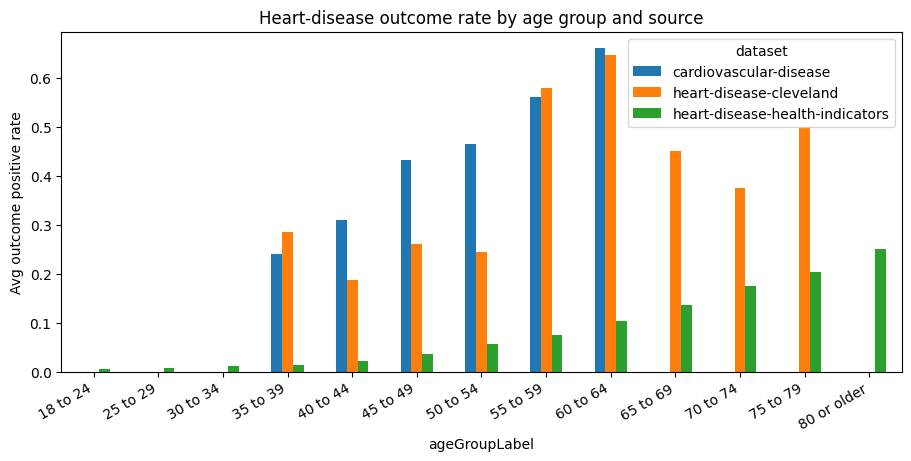

dataset,cardiovascular-disease,heart-disease-cleveland,heart-disease-health-indicators
ageGroupLabel,,,
18 to 24,NaN,NaN,0.005063
25 to 29,0.000000,0.000000,0.007098
30 to 34,0.000000,0.000000,0.011274
35 to 39,0.240809,0.285714,0.013994
40 to 44,0.310314,0.187931,0.022358
45 to 49,0.432157,0.260869,0.036507
50 to 54,0.464998,0.243860,0.055535
55 to 59,0.561267,0.580000,0.075655
60 to 64,0.662238,0.647728,0.104089


In [24]:
outcome_by_age = query_to_df(graph, (SPARQL_DIR / '07_outcome_rate_by_age_group.rq').read_text())
outcome_by_age['avgOutcomeRate'] = pd.to_numeric(outcome_by_age['avgOutcomeRate'], errors='coerce')
outcome_by_age['totalObservations'] = pd.to_numeric(outcome_by_age['totalObservations'], errors='coerce')

pivot = outcome_by_age.pivot_table(
    index='ageGroupLabel',
    columns=outcome_by_age['dataset'].str.split('/').str[-1],
    values='avgOutcomeRate',
)
if plt is not None:
    fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
    pivot.plot(kind='bar', ax=ax)
    ax.set_ylabel('Avg outcome positive rate')
    ax.set_title('Heart-disease outcome rate by age group and source')
    plt.xticks(rotation=30, ha='right')
    plt.show()
pivot


### 4.6 Risk-factor co-occurrence in positive records (full graph)

This is the only query that benefits from the **full** KG (`health_risk_kg.ttl`) because it traverses `hr:hasObservedRiskFactor` on individual `hr:HealthRecord` resources. We load it lazily so the rest of the notebook stays light.

In [25]:
full_graph_path = resolve_kg_path(manifest['storage']['graph_file'])
full_format = 'nt' if full_graph_path.suffix.lower() == '.nt' else 'turtle'
full_graph = Graph()
full_graph.parse(str(full_graph_path), format=full_format)
print(f'Loaded full KG: {len(full_graph):,} triples from {full_graph_path}')

Loaded full KG: 3,635,316 triples from /mnt/c/Users/Paess/Documents/GitHub/bda-practica2/Part4_Exploitation_zone/exploitation_zone/kg/health_risk_kg.ttl


In [ ]:
cooccurrence = query_to_df(full_graph, (SPARQL_DIR / '08_top_risk_factor_cooccurrence.rq').read_text())
cooccurrence['coOccurringRecords'] = pd.to_numeric(cooccurrence['coOccurringRecords'], errors='coerce')
cooccurrence

In [ ]:
if not cooccurrence.empty:
    cooccurrence['pair'] = cooccurrence['indicator1Label'] + ' & ' + cooccurrence['indicator2Label']
    if plt is not None:
        fig, ax = plt.subplots(figsize=(8.5, 5.5), constrained_layout=True)
        ax.barh(cooccurrence['pair'].head(15)[::-1], cooccurrence['coOccurringRecords'].head(15)[::-1], color='#5C8FA1')
        ax.set_xlabel('Co-occurring heart-disease positive records')
        ax.set_title('Most frequent risk-factor pairs in positive records')
        plt.show()
cooccurrence.head(15)


,indicator1Label,indicator2Label,coOccurringRecords,pair
0,High blood pressure flag,High cholesterol flag,24418,High blood pressure flag & High cholesterol flag
1,High blood pressure flag,Smoking flag,13771,High blood pressure flag & Smoking flag
2,High cholesterol flag,Smoking flag,11707,High cholesterol flag & Smoking flag
3,Difficulty walking flag,High blood pressure flag,8036,Difficulty walking flag & High blood pressure ...
4,Difficulty walking flag,High cholesterol flag,7160,Difficulty walking flag & High cholesterol flag
5,Difficulty walking flag,Smoking flag,6472,Difficulty walking flag & Smoking flag
6,Glucose risk flag,High blood pressure flag,5737,Glucose risk flag & High blood pressure flag
7,Glucose risk flag,High cholesterol flag,4374,Glucose risk flag & High cholesterol flag
8,Heavy alcohol consumption flag,High blood pressure flag,2283,Heavy alcohol consumption flag & High blood pr...
9,Heavy alcohol consumption flag,Smoking flag,1456,Heavy alcohol consumption flag & Smoking flag


In [ ]:
if report is not None:
    print('Report timestamp:', report['run_at_utc'])
    print('Graph structure :', report['graph_structure'])
    print('Queries executed:', [q['query'] for q in report['queries']])
else:
    print('Run Part5_KG_Analysis first to generate the JSON report.')

Report timestamp: 2026-06-01T15:06:59+00:00
Graph structure : {'datasets': 3, 'indicators': 17, 'population_groups': 26, 'age_groups': 13, 'outcomes': 3, 'aggregate_measurements': 645}
Queries executed: ['02_indicators_shared_by_datasets.rq', '03_rank_population_groups_by_outcome_rate.rq', '04_combine_indicators_same_group.rq', '06_indicator_consistency_across_datasets.rq', '07_outcome_rate_by_age_group.rq', '05_population_groups_connected_to_multiple_sources.rq', '08_top_risk_factor_cooccurrence.rq']
